In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)


**Explanation + Motivation**

UVA is a very highly ranked public university, unanimously considered to be one of the best in the United States. I thought it would be interesting to compare UVA with other highly ranked public universities. To do this, I used niche.com's list of the top 10 public universities in the United States. 

In [25]:
#comparing to UVA to peer institutions. for 'peer institutions' I have decided I will use niche's list of
#the top 10 public universities
top_unis = ['University of Virginia',
    'University of Michigan - Ann Arbor',
    'University of California, Los Angeles',
    'University of Virginia',
    'Georgia Institute of Technology',
    'University of California, Berkeley',
    'University of North Carolina - Chapel Hill',
    'University of Florida',
    'University of Texas at Austin',
    'University of California, San Diego',
    'University of Georgia']

df_unis = df[df['Institution Name'].isin(top_unis)]
df_unis.head()
#check and make sure new df has all appropriate unis
print(df_unis['Institution Name'].nunique())

10


The first thing I wanted to look at was how UVA compares in total foreign gifts.

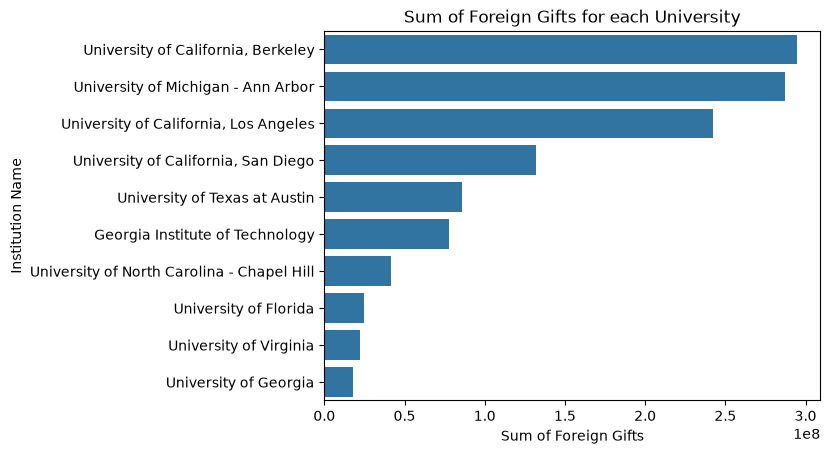

In [130]:

inst_gift_sums = df_unis.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
sns.barplot(x = inst_gift_sums.values, y = inst_gift_sums.index)
plt.xlabel('Sum of Foreign Gifts')
plt.title('Sum of Foreign Gifts for each University')
plt.show()

UVA is ranked as the #3 institution on Niche's top public university list, but is at the lower end of these universities when it comes to total money received from foreign gifts. It is not necessarily a bad thing since all of these universities are different sizes, run different programs, etc. However, it is an interesting observation to note. 

<Axes: ylabel='Institution Name'>

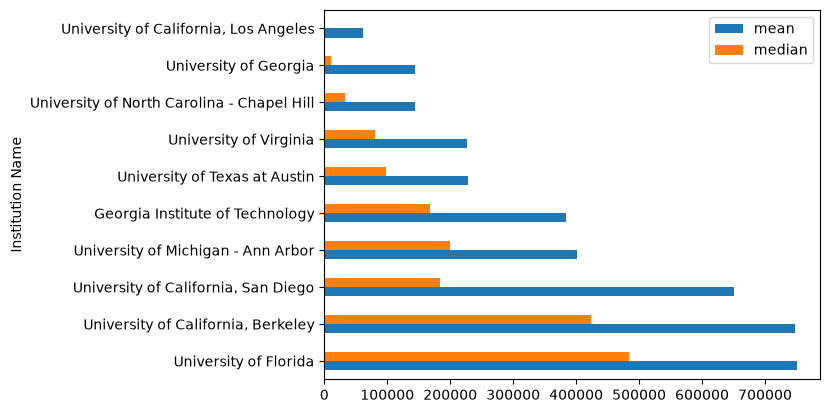

In [128]:
gift_amts = df_unis.groupby('Institution Name')['Foreign Gift Amount'].agg(mean='mean', median='median').sort_values('mean', ascending=False)
gift_amts.plot(kind='barh')

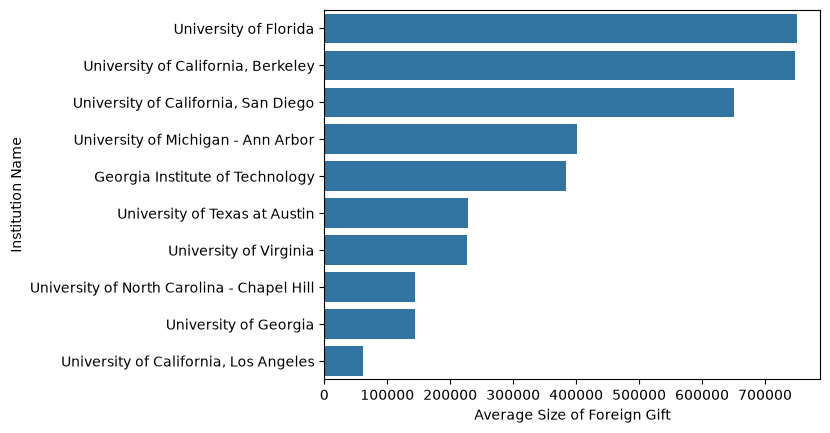

In [38]:
mean_vals = df_unis.groupby('Institution Name')['Foreign Gift Amount'].mean().sort_values(ascending=False)
sns.barplot(x = mean_vals.values, y = mean_vals.index)
plt.xlabel('Average Size of Foreign Gift')
plt.show()

In [52]:
gift_comparison = df_unis.groupby('Institution Name')['Foreign Gift Amount'].agg(['mean', 'median']).sort_values('mean', ascending=False)

gift_comparison

,mean,median
Institution Name,,
University of Florida,750276.939394,483216.0
"University of California, Berkeley",747410.923858,424025.0
"University of California, San Diego",649959.384236,184141.0
University of Michigan - Ann Arbor,401869.626573,200000.0
Georgia Institute of Technology,384134.783251,167435.0
University of Texas at Austin,227741.135279,97911.0
University of Virginia,226420.795918,80535.5
University of North Carolina - Chapel Hill,144379.524476,33548.0
University of Georgia,143530.314516,11230.0


I find it interesting that among these universities, UCLA ranks #3 in sum of foreign gifts, yet has such a low median gift amount that it is not visible on the bar plot. They have a very large discreptancy between mean and median.

I now want to look at the largest donation flows to these institutions using crosstab.

In [132]:
gift_compare_withcounts = df_unis.groupby('Institution Name')['Foreign Gift Amount'].agg(['count', 'sum', 'mean', 'median']
).sort_values('sum', ascending=False)

gift_compare_withcounts



,count,sum,mean,median
Institution Name,,,,
"University of California, Berkeley",394,294479904,747410.923858,424025.0
University of Michigan - Ann Arbor,715,287336783,401869.626573,200000.0
"University of California, Los Angeles",3916,242146363,61835.128447,250.0
"University of California, San Diego",203,131941755,649959.384236,184141.0
University of Texas at Austin,377,85858408,227741.135279,97911.0
Georgia Institute of Technology,203,77979361,384134.783251,167435.0
University of North Carolina - Chapel Hill,286,41292544,144379.524476,33548.0
University of Florida,33,24759139,750276.939394,483216.0
University of Virginia,98,22189238,226420.795918,80535.5


In [134]:
med_counts = gift_compare_withcounts['count'].median()
print(f'median gift count: {med_counts}')

median gift count: 244.5


UCLA seems to be an outlier here, as it receives a massive total number of gifts, along with a very low median gift amount. UVA is definitely on the lower end of this list for total number of gifts received. 

In [105]:
ctab_df = pd.crosstab(index=df_unis['Country of Giftor'], columns=df_unis['Institution Name'],values=df_unis['Foreign Gift Amount'], aggfunc='sum')

top_10_df = (ctab_df.stack().dropna().reset_index(name='Amount').sort_values(by='Amount', ascending=False).head(10))

for index, row in top_10_df.iterrows():
    print(f"{row['Country of Giftor']} gave {row['Institution Name']}: ${row['Amount']:,.2f}")

ENGLAND gave University of California, Los Angeles: $53,959,295.00
JAPAN gave University of California, Los Angeles: $52,335,423.00
ENGLAND gave University of Michigan - Ann Arbor: $46,023,031.00
INDIA gave University of California, San Diego: $35,888,789.00
CHINA gave University of California, Berkeley: $35,876,428.00
GERMANY gave University of California, San Diego: $34,315,880.00
JAPAN gave University of Michigan - Ann Arbor: $32,242,238.00
GERMANY gave University of California, Berkeley: $28,890,715.00
ENGLAND gave University of California, Berkeley: $27,428,324.00
CHINA gave University of Michigan - Ann Arbor: $27,298,052.00


UVA does not appear on this list of the largest country-to-institution flows.

I will see if there is a noticeable difference between the countries UVA receives its money from.

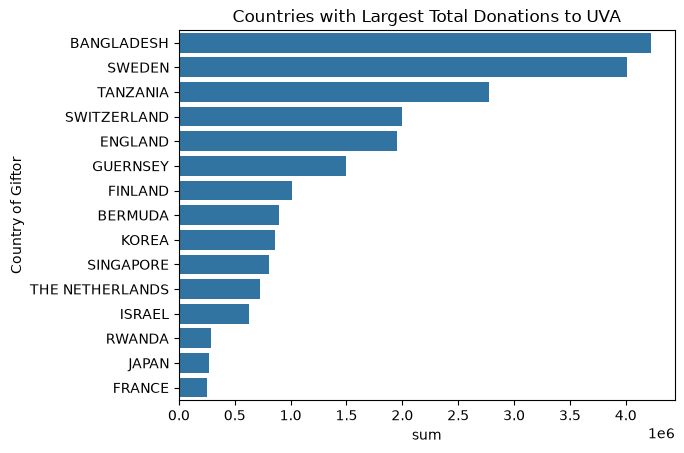

In [116]:
uva_df = df[df['Institution Name'] == 'University of Virginia']

money_gifted = uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].agg(['sum', 'count']).sort_values('sum', ascending=False)

sns.barplot(y = money_gifted.index, x = money_gifted['sum'])
plt.title('Countries with Largest Total Donations to UVA')
plt.show()


I will now compare UVA to all institutions in the dataset, using quantiles. I will see what quantile of sum of donations UVA falls in. 

In [104]:
uni_sums = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
uva_total = uni_sums.loc['University of Virginia']

quantile = round(np.mean(uni_sums.values <= uva_total), 4)*100
print(f'When comparing UVA to all universities in the dataset, UVA falls into the {quantile}th quantile in terms of total money received.')

When comparing UVA to all universities in the dataset, UVA falls into the 68.55th quantile in terms of total money received.


In [ ]:
gift_type_pct = pd.crosstab(df_unis['Institution Name'], df_unis['Gift Type'], values=df_unis['Foreign Gift Amount'],
    aggfunc='sum', normalize='index'
)*100

gift_type_pct_signed = gift_type_pct.map(lambda x: f"{x:.1f}%")
gift_type_pct_signed

Gift Type,Contract,Monetary Gift
Institution Name,,
Georgia Institute of Technology,79.7%,20.3%
"University of California, Berkeley",57.6%,42.4%
"University of California, Los Angeles",65.6%,34.4%
"University of California, San Diego",62.9%,37.1%
University of Florida,99.0%,1.0%
University of Georgia,100.0%,0.0%
University of Michigan - Ann Arbor,84.2%,15.8%
University of North Carolina - Chapel Hill,89.2%,10.8%
University of Texas at Austin,83.6%,16.4%
